# π-Flow на 2D-спиральках: DX и GMFlow честно

Минимальный, но полный пример к конспекту **pi-flow.md**: как на самом деле устроены
DX- и GMFlow-политики π-Flow. Всё на CPU, данные 2D.

**Главная мысль notebook'а:** один и тот же простой **base π-ID** (катим студент-политику,
матчим её мгновенную скорость к учителю) — **GMFlow обучает прекрасно** (она робастна
по построению), а **DX на нём коллапсирует**. Чтобы DX заработал, нужен более аккуратный
рецепт: **off-policy** rollout (катимся по траектории учителя) + **оконно-усреднённая** скорость.

**Конвенция времени:** $x_t = (1-t)x_0 + t\varepsilon$, $t: 1 \to 0$ ($t{=}1$ шум, $t{=}0$ данные),
скорость $v = \varepsilon - x_0 = (x_t-x_0)/t$, PF-ODE $dx_t/dt = (x_t - \mathbb{E}[x_0|x_t])/t$.

> ⏱ Полный прогон ~20 мин на CPU (дольше всего — hero-DX с off-policy rollout). Можно
> уменьшить `n_steps`. Все картинки уже встроены — запускать не обязательно.

In [2]:
# π-Flow on 2D spirals (v2). CPU-only.
%matplotlib inline
import math
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import trange

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cpu")

# spiral colors: red / blue / orange (как на рисунке)
SPIRAL_COLORS = ["#E74C3C", "#3B7DD8", "#E59A1C"]
DX_COLOR, GMFLOW_COLOR, TEACHER_COLOR = "#2E86DE", "#27AE60", "#9B59B6"
print("torch", torch.__version__)

torch 2.12.0


/Users/user014/anaconda3/envs/piflow-toy/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Part 0 — Данные

Три архимедовы спиральки в разных центрах — мультимодальная цель: из гауссова шума надо
попасть в любую из трёх спиралей и пройти по завитку.

data (6000, 2)


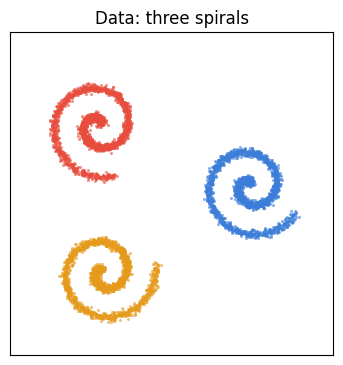

In [3]:
def make_spirals(n_points=6000, noise_std=0.04, turns=1.8, arm_length=1.05):
    """Generate three spirals centered at three different points.

    Returns:
        data:   (n_points, 2) point coordinates
        labels: (n_points,)   spiral index in {0, 1, 2}
    """
    centers = torch.tensor([[-1.45, 1.35], [1.55, 0.15], [-1.35, -1.55]])
    points_per_spiral = n_points // 3
    all_points, all_labels = [], []
    for spiral_idx in range(3):
        progress = torch.linspace(0.05, 1.0, points_per_spiral)   # 0..1 along the spiral
        angle = progress * turns * 2 * math.pi + spiral_idx * 0.7
        radius = progress * arm_length
        x = centers[spiral_idx, 0] + radius * torch.cos(angle) + torch.randn(points_per_spiral) * noise_std
        y = centers[spiral_idx, 1] + radius * torch.sin(angle) + torch.randn(points_per_spiral) * noise_std
        all_points.append(torch.stack([x, y], dim=1))
        all_labels.append(torch.full((points_per_spiral,), spiral_idx))
    data = torch.cat(all_points, dim=0)
    labels = torch.cat(all_labels, dim=0)
    permutation = torch.randperm(len(data))
    return data[permutation], labels[permutation]


def scatter(ax, points, labels=None, size=5, alpha=0.6):
    """Scatter helper with fixed axes so every panel is directly comparable."""
    if labels is None:
        ax.scatter(points[:, 0], points[:, 1], s=size, c="#444", alpha=alpha, linewidths=0)
    else:
        for spiral_idx in range(3):
            mask = labels == spiral_idx
            ax.scatter(points[mask, 0], points[mask, 1], s=size,
                       c=SPIRAL_COLORS[spiral_idx], alpha=alpha, linewidths=0)
    ax.set_aspect("equal")
    ax.set_xlim(-3.2, 3.2)
    ax.set_ylim(-3.2, 3.2)
    ax.set_xticks([])
    ax.set_yticks([])


data, labels = make_spirals()
print("data", tuple(data.shape))

fig, ax = plt.subplots(figsize=(4.2, 4.2))
scatter(ax, data, labels)
ax.set_title("Data: three spirals")
plt.show()

## Part 1 — Teacher: flow matching

Учим сеть предсказывать скорость $v(x_t,t)$, таргет $(\varepsilon - x_0)$. На инференсе интегрируем
ODE от $t{=}1$ к $t{=}0$. **EMA весов** даёт более чистые сэмплы.

In [4]:
# ---- shared infrastructure: time embedding, MLP trunk, EMA, MMD metric ----
def sinusoidal_time_embedding(t, dim, scale=80.0):
    """Map scalar time t (per sample) to a `dim`-vector of sines/cosines (DDPM-style)."""
    half_dim = dim // 2
    frequencies = torch.exp(-math.log(10000) * torch.arange(half_dim, dtype=t.dtype) / half_dim)
    angles = (t * scale).unsqueeze(-1) * frequencies
    return torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)


class MLP(nn.Module):
    """Plain SiLU MLP trunk shared by the teacher and both policies."""

    def __init__(self, input_dim, output_dim, hidden_dim=384, n_layers=5):
        super().__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.SiLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.SiLU()]
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class EMA:
    """Exponential moving average of model weights — gives much cleaner samples."""

    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {name: param.detach().clone() for name, param in model.state_dict().items()}

    def update(self, model):
        for name, param in model.state_dict().items():
            if param.dtype.is_floating_point:
                self.shadow[name].mul_(self.decay).add_(param.detach(), alpha=1 - self.decay)
            else:
                self.shadow[name] = param.detach().clone()

    def make(self, model):
        """Return a copy of `model` loaded with the averaged weights (eval mode)."""
        averaged = copy.deepcopy(model)
        averaged.load_state_dict(self.shadow)
        averaged.eval()
        return averaged


def mmd(generated, data, bandwidth=0.3):
    """Gaussian-kernel Maximum Mean Discrepancy to the data (lower = better).

    Note: bandwidth 0.3 is coarse — it sees the three modes but barely the thin spiral
    curl, so 'blobs' and 'spirals' can get similar scores.
    """
    def gaussian_kernel(points_a, points_b):
        sq_dist = (points_a.unsqueeze(1) - points_b.unsqueeze(0)).pow(2).sum(-1)
        return torch.exp(-sq_dist / (2 * bandwidth ** 2))

    return (gaussian_kernel(generated, generated).mean()
            + gaussian_kernel(data, data).mean()
            - 2 * gaussian_kernel(generated, data).mean()).item()

In [5]:
class VelocityNet(nn.Module):
    """Teacher velocity field v(x_t, t) -> R^2 (standard flow-matching model)."""

    def __init__(self, time_dim=128):
        super().__init__()
        self.time_dim = time_dim
        self.mlp = MLP(2 + time_dim, 2)

    def forward(self, x, t):
        if t.dim() == 0:
            t = t.expand(x.shape[0])
        return self.mlp(torch.cat([x, sinusoidal_time_embedding(t, self.time_dim)], dim=-1))


def train_flow_matching(model, data, n_steps=12000, batch_size=512, lr=1e-3, ema_decay=0.999):
    """Flow matching: x_t = (1-t)x0 + t*noise ; regress v(x_t, t) -> (noise - x0). Returns the EMA."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    ema = EMA(model, ema_decay)
    n_data = len(data)
    for _ in trange(n_steps, desc="teacher FM"):
        x0 = data[torch.randint(0, n_data, (batch_size,))]
        noise = torch.randn_like(x0)
        t = torch.rand(batch_size)
        x_t = (1 - t).unsqueeze(-1) * x0 + t.unsqueeze(-1) * noise
        loss = ((model(x_t, t) - (noise - x0)) ** 2).sum(-1).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        ema.update(model)
    return ema


@torch.no_grad()
def sample_ode(velocity, n_samples, n_steps, x_init=None, return_trajectory=False):
    """Integrate dx = v*dt from t=1 (noise) to t=0 (data) with `n_steps` Euler steps."""
    x = torch.randn(n_samples, 2) if x_init is None else x_init.clone()
    times = torch.linspace(1.0, 0.0, n_steps + 1)
    trajectory = [x.clone()]
    for i in range(n_steps):
        x = x + velocity(x, times[i].expand(len(x))) * (times[i + 1] - times[i])
        trajectory.append(x.clone())
    return (x, trajectory) if return_trajectory else x


teacher_net = VelocityNet()
teacher = train_flow_matching(teacher_net, data).make(teacher_net)

teacher FM: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12000/12000 [02:25<00:00, 82.50it/s]


MMD  teacher@200=0.0005   teacher@4=0.0167


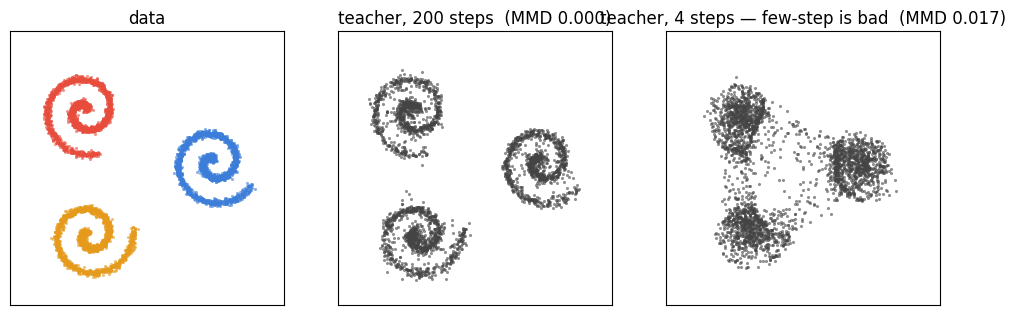

In [6]:
samples_teacher = sample_ode(teacher, 3000, 200)
samples_teacher_4step = sample_ode(teacher, 3000, 4)
print(f"MMD  teacher@200={mmd(samples_teacher, data):.4f}   teacher@4={mmd(samples_teacher_4step, data):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
scatter(axes[0], data, labels)
axes[0].set_title("data")
scatter(axes[1], samples_teacher)
axes[1].set_title(f"teacher, 200 steps  (MMD {mmd(samples_teacher, data):.3f})")
scatter(axes[2], samples_teacher_4step)
axes[2].set_title(f"teacher, 4 steps — few-step is bad  (MMD {mmd(samples_teacher_4step, data):.3f})")
plt.show()

**Поле скорости учителя (направление генерации).** Рисуем $-v$: ODE идёт $t:1\to0$, и сэмплы движутся
вдоль $-v$ — то есть **к спиралям**. Поэтому стрелки втыкаются в данные, а не смотрят от них.

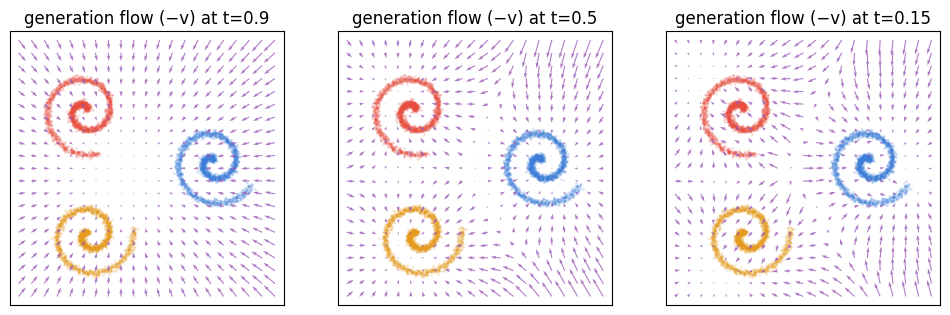

In [7]:
grid_axis = torch.linspace(-3, 3, 21)
grid_x, grid_y = torch.meshgrid(grid_axis, grid_axis, indexing="xy")
grid_points = torch.stack([grid_x.reshape(-1), grid_y.reshape(-1)], dim=1)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, t_value in zip(axes, [0.9, 0.5, 0.15]):
    with torch.no_grad():
        velocity_field = teacher(grid_points, torch.full((len(grid_points),), t_value))
    scatter(ax, data, labels, size=3, alpha=0.25)
    # plot -v: the generation direction (toward data / the spirals)
    ax.quiver(grid_points[:, 0], grid_points[:, 1], -velocity_field[:, 0], -velocity_field[:, 1],
              color=TEACHER_COLOR, alpha=0.8, width=0.004)
    ax.set_title(f"generation flow (−v) at t={t_value}")
plt.show()

## Part 2 — Идея π-Flow и π-ID

Стандартная дистилляция: 1 вызов сети = 1 шаг ODE. π-Flow: один forward выдаёт **политику** —
функцию скорости на сегменте, которую потом интегрируют **густо и без новых вызовов сети**.

**π-ID** учит политику имитировать учителя (DAgger): катим политику до промежуточной точки $x_t$,
там спрашиваем скорость учителя и матчим к ней скорость политики ($\ell_2$). Две оси, которые
дальше окажутся решающими для DX:
- **on-policy** (катимся по самой студент-политике) ↔ **off-policy** (катимся по траектории **учителя**);
- **мгновенный** матч ↔ **оконно-усреднённый** (среднее скорости по микро-окну $\Delta t$).

## Part 3 — DX policy

Сеть из старта $(x_{src}, t_{src})$ выдаёт **сетку из $N$ velocity** $u_i$; они один раз
переводятся в сетку $\hat x_0$: $\;\hat x_0^{(i)} = x_{src} - t_{src}\,u_i$ (u-to-x0). Скорость в
любой точке — линейная интерполяция сетки $\hat x_0$ + формула $\pi=(x-\hat x_0(t))/t$ (сеть не зовём).

Рабочий рецепт обучения DX:
- **off-policy BC**: rollout катим **шагами учителя** (стабильно — студент не уводит траекторию);
- **window-avg**: скорость студента берём как среднюю по микро-окну (секанс), а не мгновенную.

> Две оси времени: `raw_t` — равномерная ось [0,1] для нарезки сегментов; `sigma` — реальный
> уровень шума в $x_t$. Их связывает `shift`: $\sigma = \mathrm{shift}(\text{raw\_t})$. При `shift=1`
> они совпадают (sigma == raw_t).

**Основные гиперпараметры обучения** (полезно держать в голове; `lr`/`batch_size` опускаю — они всегда есть):
- `nfe` — сколько вызовов сети (= шагов студента) на генерацию. У нас **1**. Задаётся при обучении
  и на инференсе **не меняется свободно** (политика обучена под сегмент размера 1/nfe).
- `num_anchors` — сколько точек сравнения с учителем на один forward студента.
- `policy_mode` — **off** / **on**-policy: чем катимся до якоря (учителем или самой политикой).
- `window_substeps` (+ его размер) — окно усреднения скорости студента; **0** = мгновенная.
- `shift` — расписание timesteps (у нас **1**, тогда `sigma == raw_t`).

> **Слабость DX (важно):** политика — это **замороженный план** (сетка $\hat x_0$), она **не смотрит
> на $x_t$**. Сказали «направо, потом налево» — и если чуть ошиблись в начале, ошибка **быстро растёт**:
> следующие «команды» считают, что ты на правильной дороге. Отсюда хрупкость и нужда в off-policy + window.

> **На инференсе** сэмплим **EMA-весами** (чище), а не сырыми.

In [8]:
def raw_t_to_sigma(raw_t, shift):
    """Map the uniform time raw_t in [0,1] to the actual noise level sigma (shift schedule)."""
    return shift * raw_t / (1 + (shift - 1) * raw_t)


def sigma_to_raw_t(sigma, shift):
    """Inverse of raw_t_to_sigma."""
    return sigma / (shift + (1 - shift) * sigma)


def interpolate_grid(grid, position):
    """Per-sample linear interpolation over a grid of N points.

    grid:     (B, N, 2) the N grid values; index 0 = data side, index N-1 = noise side.
    position: (B,) where in [0, 1] to sample (0 -> index 0, 1 -> index N-1).
    """
    n_grid = grid.size(1)
    if n_grid < 2:
        return grid[:, 0]
    scaled = position.clamp(0, 1) * (n_grid - 1)
    idx_low = scaled.floor().long().clamp(0, n_grid - 2)
    idx_high = idx_low + 1
    weight_high = (scaled - idx_low.float()).unsqueeze(-1)
    batch_idx = torch.arange(grid.size(0))
    grid_low = grid[batch_idx, idx_low]
    grid_high = grid[batch_idx, idx_high]
    return grid_low * (1 - weight_high) + grid_high * weight_high


class DXPolicyNet(nn.Module):
    """DX network: from (x_src, t_src) outputs a grid of N velocity vectors u_i -> (B, N, 2)."""

    def __init__(self, n_grid=24, time_dim=128):
        super().__init__()
        self.n_grid = n_grid
        self.time_dim = time_dim
        self.mlp = MLP(2 + time_dim, n_grid * 2)

    def forward(self, x_src, t_src):
        if t_src.dim() == 0:
            t_src = t_src.expand(x_src.shape[0])
        out = self.mlp(torch.cat([x_src, sinusoidal_time_embedding(t_src, self.time_dim)], dim=-1))
        return out.view(-1, self.n_grid, 2)


class DXPolicy:
    """Network-free DX policy on one segment [raw_t_dst, raw_t_src], built from one network output."""

    def __init__(self, velocity_grid, x_src, sigma_src, raw_t_src, segment_size, shift, epsilon=1e-4):
        # u-to-x0: turn the N predicted velocities into N clean-point estimates x_hat_0.
        self.x0_grid = x_src.unsqueeze(1) - sigma_src.view(-1, 1, 1) * velocity_grid   # (B, N, 2)
        self.raw_t_src = raw_t_src
        self.segment_size = segment_size
        self.shift = shift
        self.epsilon = epsilon
        self.raw_t_dst = (raw_t_src - segment_size).clamp(min=0)

    def velocity(self, x, sigma):
        """The policy velocity pi(x, sigma) — pure arithmetic, no network call."""
        raw_t = sigma_to_raw_t(sigma, self.shift)
        segment_position = ((raw_t - self.raw_t_dst) / self.segment_size).clamp(0, 1)
        x0_interp = interpolate_grid(self.x0_grid, segment_position)
        return (x - x0_interp) / sigma.clamp_min(self.epsilon).unsqueeze(-1)

    def detach(self):
        """Stop-gradient copy (used for rollout, where no gradient should flow)."""
        copied = copy.copy(self)
        copied.x0_grid = self.x0_grid.detach()
        return copied


def rollout(velocity, x, raw_t_from, raw_t_to, num_substeps, shift):
    """Euler-integrate `velocity(x, sigma)` from raw_t_from down to raw_t_to (per-sample).

    Returns the final x and the final sigma. shift=1 -> sigma == raw_t.
    """
    for step in range(num_substeps):
        raw_t = raw_t_from + (raw_t_to - raw_t_from) * (step / num_substeps)
        raw_t_next = raw_t_from + (raw_t_to - raw_t_from) * ((step + 1) / num_substeps)
        sigma = raw_t_to_sigma(raw_t, shift)
        sigma_next = raw_t_to_sigma(raw_t_next, shift)
        x = x + velocity(x, sigma) * (sigma_next - sigma).unsqueeze(-1)
    return x, raw_t_to_sigma(raw_t_to, shift)


TOTAL_SUBSTEPS = 64

In [ ]:
1 -> 0.85 -> 0.7 -> 0.5 -> 0

In [9]:
def train_dx(policy_net, teacher, data, nfe=1, shift=1.0, policy_mode="off", window_substeps=3,
             num_anchors=2, n_steps=4000, batch_size=512, lr=5e-4, grad_clip=1.0,
             substeps_to_anchor_cap=16, ema_decay=0.999, desc="DX"):
    """DX pi-ID on the 2D toy problem (full policy-distillation recipe).

    policy_mode = 'off' -> roll the anchors along the TEACHER (stable behavior cloning);
                  'on'  -> roll along the student policy itself (fragile).
    window_substeps > 0 -> student velocity is the AVERAGE over a micro-window (secant),
                           the stabilizer; window_substeps = 0 -> instantaneous.
    """
    optimizer = torch.optim.Adam(policy_net.parameters(), lr=lr)
    ema = EMA(policy_net, ema_decay)
    window_size = window_substeps / TOTAL_SUBSTEPS
    n_data = len(data)
    substeps_to_anchor = max(1, min(substeps_to_anchor_cap, round((1.0 / nfe) * TOTAL_SUBSTEPS)))

    for _ in trange(n_steps, desc=desc):
        x0 = data[torch.randint(0, n_data, (batch_size,))]
        noise = torch.randn_like(x0)
        segment_idx = int(torch.randint(1, nfe + 1, (1,)))
        raw_t_src = torch.full((batch_size,), segment_idx / nfe)
        segment_size = torch.full((batch_size,), 1.0 / nfe)
        sigma_src = raw_t_to_sigma(raw_t_src, shift)   # sigma = shift(raw_t); for shift=1, sigma == raw_t
        x_src = (1 - sigma_src).unsqueeze(-1) * x0 + sigma_src.unsqueeze(-1) * noise   # data-dependent start
        policy = DXPolicy(policy_net(x_src, sigma_src), x_src, sigma_src, raw_t_src, segment_size, shift)
        policy_detached = policy.detach()

        loss = 0.0
        for _ in range(num_anchors):
            raw_t_anchor = raw_t_src - torch.rand(batch_size) * (segment_size - window_size).clamp_min(1e-4)
            # --- axis 1: HOW we reach the anchor (on/off-policy) ---
            #   off-policy: integrate along the TEACHER -> anchor stays on the correct trajectory (stable)
            #   on-policy : integrate along the student -> anchor goes wherever the student drifts (fragile)
            with torch.no_grad():
                roll_velocity = (lambda pt, sig: teacher(pt, sig)) if policy_mode == "off" else policy_detached.velocity
                x_anchor, _ = rollout(roll_velocity, x_src, raw_t_src, raw_t_anchor, substeps_to_anchor, shift)
            sigma_anchor = raw_t_to_sigma(raw_t_anchor, shift)
            target_velocity = teacher(x_anchor, sigma_anchor).detach()
            # --- axis 2: HOW we read the student velocity at the anchor (window or not) ---
            if window_substeps <= 0:
                student_velocity = policy.velocity(x_anchor, sigma_anchor)               # instantaneous (fragile for DX)
            else:
                # window-averaged: secant (delta_x / delta_sigma) over a micro-window — the stabilizer DX needs
                raw_t_window_end = (raw_t_anchor - window_size).clamp(min=1e-4)
                x_window_end, sigma_window_end = rollout(policy.velocity, x_anchor, raw_t_anchor,
                                                         raw_t_window_end, window_substeps, shift)
                student_velocity = (x_anchor - x_window_end) / (sigma_anchor - sigma_window_end).clamp_min(1e-4).unsqueeze(-1)
            loss = loss + ((student_velocity - target_velocity) ** 2).sum(-1).mean()
        loss = loss / num_anchors

        optimizer.zero_grad()
        loss.backward()
        if grad_clip:
            torch.nn.utils.clip_grad_norm_(policy_net.parameters(), grad_clip)
        optimizer.step()
        ema.update(policy_net)
    return ema


@torch.no_grad()
def sample_dx(policy_net, n_samples, nfe, shift=1.0, return_trajectory=False):
    """Generate with `nfe` network calls: one DX forward per segment, then dense network-free integration."""
    x = torch.randn(n_samples, 2)
    trajectory = [x.clone()]
    for segment_i in range(nfe):
        raw_t_src = torch.full((n_samples,), 1 - segment_i / nfe)
        raw_t_dst = torch.full((n_samples,), max(1e-3, 1 - (segment_i + 1) / nfe))
        segment_size = torch.full((n_samples,), 1.0 / nfe)
        sigma_src = raw_t_to_sigma(raw_t_src, shift)
        policy = DXPolicy(policy_net(x, sigma_src), x, sigma_src, raw_t_src, segment_size, shift)   # 1 network call
        n_substeps = max(1, round((1.0 / nfe) * TOTAL_SUBSTEPS))
        for step in range(n_substeps):                                                             # network-free
            raw_t = raw_t_src + (raw_t_dst - raw_t_src) * (step / n_substeps)
            raw_t_next = raw_t_src + (raw_t_dst - raw_t_src) * ((step + 1) / n_substeps)
            sigma = raw_t_to_sigma(raw_t, shift)
            sigma_next = raw_t_to_sigma(raw_t_next, shift)
            x = x + policy.velocity(x, sigma) * (sigma_next - sigma).unsqueeze(-1)
            trajectory.append(x.clone())
    return (x, trajectory) if return_trajectory else x

**Hero-DX — рабочий рецепт.** **off-policy** rollout (катимся
по учителю) + **window-avg** скорость, 1-NFE, $N{=}24$. Единственная конфигурация DX, что ловит все
три моды — ниже видно, как снятие любого из двух костылей её ломает.

DX off+window: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4000/4000 [08:58<00:00,  7.43it/s]


MMD DX 1-NFE (off-policy + window) = 0.0026


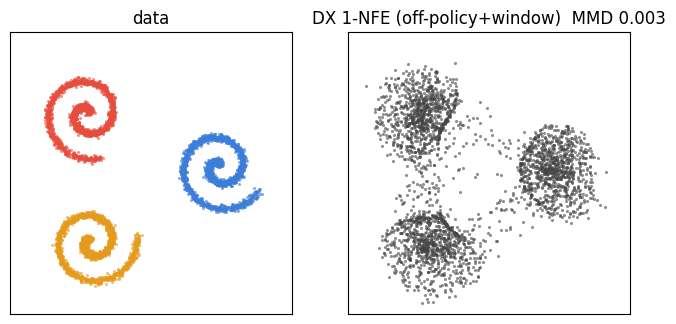

In [10]:
# Hero DX: the real recipe — off-policy BC + window-avg, 1-NFE, N=24.
dx_policy_net = DXPolicyNet(n_grid=24)
dx_ema = train_dx(dx_policy_net, teacher, data, nfe=1, policy_mode="off", window_substeps=3,
                  n_steps=4000, lr=5e-4, grad_clip=1.0, desc="DX off+window")
dx_policy = dx_ema.make(dx_policy_net)
samples_dx = sample_dx(dx_policy, 3000, nfe=1)
print(f"MMD DX 1-NFE (off-policy + window) = {mmd(samples_dx, data):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
scatter(axes[0], data, labels)
axes[0].set_title("data")
scatter(axes[1], samples_dx)
axes[1].set_title(f"DX 1-NFE (off-policy+window)  MMD {mmd(samples_dx, data):.3f}")
plt.show()

**Что значит «один forward = политика».** Для нескольких шумовых стартов вызываем сеть **один раз**,
дальше интегрируем политику **без сети** и смотрим, как она идёт к спиралям. Красные стрелки —
направление движения вдоль траектории (всё из того одного forward).

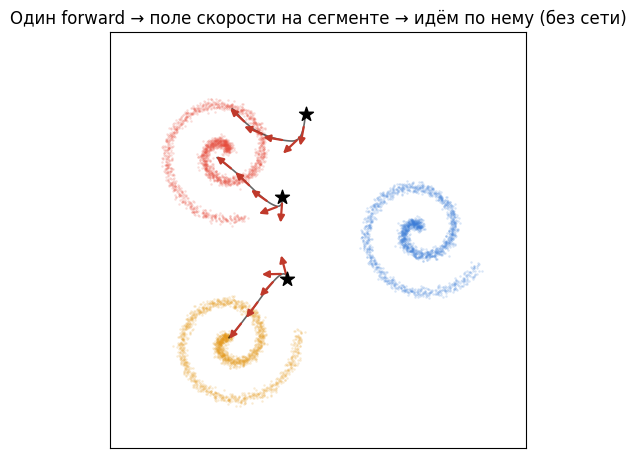

In [11]:
torch.manual_seed(5)
n_show = 3
x_init = torch.randn(n_show, 2)
ones = torch.ones(n_show)
with torch.no_grad():
    one_policy = DXPolicy(dx_policy(x_init, ones), x_init, ones, ones, ones, 1.0)   # ONE network call per start
    n_substeps = 64
    times = torch.linspace(1.0, 1e-3, n_substeps + 1)
    x = x_init.clone()
    trajectory = [x.clone()]
    for step in range(n_substeps):                                                  # network-free integration
        x = x + one_policy.velocity(x, times[step].expand(n_show)) * (times[step + 1] - times[step])
        trajectory.append(x.clone())
    trajectory = torch.stack(trajectory)

fig, ax = plt.subplots(figsize=(5.4, 5.4))
scatter(ax, data, labels, size=3, alpha=0.2)
for i in range(n_show):
    ax.plot(trajectory[:, i, 0], trajectory[:, i, 1], color="k", lw=1.2, alpha=0.6)
    ax.scatter(x_init[i, 0], x_init[i, 1], c="k", marker="*", s=110, zorder=5)
    for step in [6, 18, 30, 42, 54]:
        direction = trajectory[step + 1, i] - trajectory[step, i]
        direction = direction / (direction.norm() + 1e-8) * 0.38
        ax.annotate("", xy=(trajectory[step, i, 0] + direction[0], trajectory[step, i, 1] + direction[1]),
                    xytext=(trajectory[step, i, 0], trajectory[step, i, 1]),
                    arrowprops=dict(arrowstyle="-|>", color="#C0392B", lw=1.6))
ax.set_title("Один forward → поле скорости на сегменте → идём по нему (без сети)")
plt.show()

### Что ломает DX (failure modes)

Тот же DX, но с «неправильными» переключателями. Видно градиент деградации вплоть до коллапса.
Главный урок: **DX хрупкий** — ему нужны и off-policy, и window. (Числа MMD у failure-режимов
обучены коротко, для иллюстрации тренда.)

DX naive: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:45<00:00, 43.89it/s]


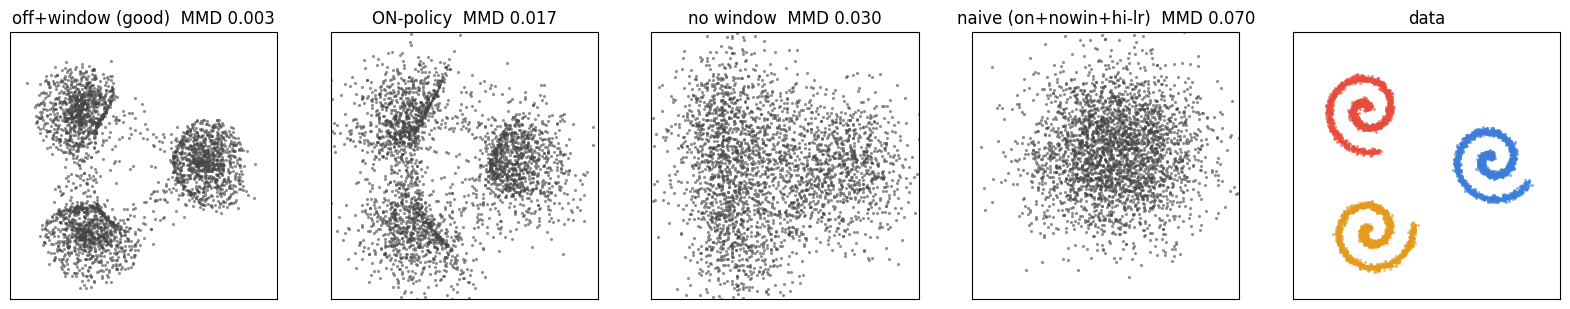

In [12]:
# Three antiregimes (short training, just to show the trend):
dx_ema_onpolicy = train_dx(DXPolicyNet(n_grid=24), teacher, data, nfe=1, policy_mode="on",
                           window_substeps=3, n_steps=2000, lr=5e-4, grad_clip=1.0, desc="DX on-policy")
dx_ema_nowindow = train_dx(DXPolicyNet(n_grid=24), teacher, data, nfe=1, policy_mode="off",
                           window_substeps=0, n_steps=2000, lr=5e-4, grad_clip=1.0, desc="DX no-window")
dx_ema_naive = train_dx(DXPolicyNet(n_grid=24), teacher, data, nfe=1, policy_mode="on",
                        window_substeps=0, n_steps=2000, lr=1e-3, grad_clip=None, desc="DX naive")

samples_onpolicy = sample_dx(dx_ema_onpolicy.make(DXPolicyNet(n_grid=24)), 3000, 1)
samples_nowindow = sample_dx(dx_ema_nowindow.make(DXPolicyNet(n_grid=24)), 3000, 1)
samples_naive = sample_dx(dx_ema_naive.make(DXPolicyNet(n_grid=24)), 3000, 1)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
panels = [(samples_dx, "off+window (good)"), (samples_onpolicy, "ON-policy"),
          (samples_nowindow, "no window"), (samples_naive, "naive (on+nowin+hi-lr)"), (data, "data")]
for ax, (points, title) in zip(axes, panels):
    if title == "data":
        scatter(ax, points, labels)
    else:
        scatter(ax, points)
        title = f"{title}  MMD {mmd(points, data):.3f}"
    ax.set_title(title)
plt.show()

## Part 4 — GMFlow policy: робастность по построению

Сеть выдаёт **гауссову смесь** над $x_0$: веса $A_k$, центры $\mu_k$, общая шкала $s$ (в 2D — смесь
над $\mathbb{R}^2$). В точке $x_t$ постериор пересчитывается в **два шага** (Bayes-update, зависит от $x_t$):

1. **Перевес компонент:** $A'_k \propto A_k\,\mathcal{N}\!\big(x_t;\,(1-t)\mu_k,\,((1-t)^2s^2+t^2)I\big)$.
2. **Сдвиг центров:** $\mu'_k = \sigma^2_{\mathrm{post}}\big(\mu_k/s^2 + (1-t)x_t/t^2\big)$, где $\sigma^2_{\mathrm{post}}=\big(1/s^2 + (1-t)^2/t^2\big)^{-1}$.

Скорость политики: $\pi=(x_t-\sum_k A'_k\mu'_k)/t$. Зависимость от $x_t$ = error correction.
Поэтому GMFlow обучается **тем же base π-ID** (on-policy + мгновенный матч), на котором DX
коллапсировал, — и просто работает.

In [13]:
class GMFlowPolicyNet(nn.Module):
    """GMFlow network: from (x_src, t_src) outputs a Gaussian mixture over x0:
    weights (B, K), centers (B, K, 2), one shared scale (B,). In 2D this is a GM over R^2."""

    def __init__(self, n_components=24, time_dim=128, min_scale=0.05):
        super().__init__()
        self.n_components = n_components
        self.time_dim = time_dim
        self.min_scale = min_scale
        self.mlp = MLP(2 + time_dim, n_components + n_components * 2 + 1)

    def forward(self, x_src, t_src):
        if t_src.dim() == 0:
            t_src = t_src.expand(x_src.shape[0])
        out = self.mlp(torch.cat([x_src, sinusoidal_time_embedding(t_src, self.time_dim)], dim=-1))
        k = self.n_components
        weights = torch.softmax(out[:, :k], dim=-1)
        centers = out[:, k:k + 2 * k].reshape(-1, k, 2)
        scale = torch.nn.functional.softplus(out[:, -1]) + self.min_scale
        return weights, centers, scale


def gmflow_velocity(weights, centers, scale, x, t, epsilon=1e-3):
    """Closed-form GMFlow velocity at point x, time t.

    prior over x0:  sum_k weights_k * N(x0; centers_k, scale^2 I)   (predicted once at segment start)
    posterior given x_t (Bayes update -> depends on x_t == robustness):
        weights'_k ∝ weights_k * N(x_t; (1-t) centers_k, ((1-t)^2 scale^2 + t^2) I)
        centers'_k = post_var * (centers_k / scale^2 + x_t (1-t) / t^2)
    velocity = (x_t - E[x0 | x_t]) / t,  E[x0 | x_t] = sum_k weights'_k centers'_k.
    """
    t = t.clamp_min(epsilon)
    one_minus_t = 1 - t
    scale_sq = scale ** 2
    evidence_var = one_minus_t ** 2 * scale_sq + t ** 2                                  # (B,)
    sq_dist = ((x.unsqueeze(1) - centers * one_minus_t.view(-1, 1, 1)) ** 2).sum(-1)     # (B, K)
    weights_post = torch.softmax(torch.log(weights + 1e-12) - 0.5 * sq_dist / evidence_var.unsqueeze(-1), dim=-1)
    posterior_var = 1.0 / (1.0 / scale_sq + one_minus_t ** 2 / t ** 2)                   # (B,)
    centers_post = posterior_var.view(-1, 1, 1) * (
        centers / scale_sq.view(-1, 1, 1) + (x * (one_minus_t / t ** 2).unsqueeze(-1)).unsqueeze(1)
    )
    expected_x0 = (weights_post.unsqueeze(-1) * centers_post).sum(1)                     # (B, 2)
    return (x - expected_x0) / t.unsqueeze(-1), weights_post, expected_x0


def train_gmflow(policy_net, teacher, n_steps=4000, batch_size=512, lr=1e-3,
                 num_substeps=48, num_anchors=2, min_t=1e-2, ema_decay=0.999):
    """Base pi-ID: on-policy student rollout + instantaneous match. (Same recipe that collapses DX.)"""
    optimizer = torch.optim.Adam(policy_net.parameters(), lr=lr)
    ema = EMA(policy_net, ema_decay)
    for _ in trange(n_steps, desc="GMFlow base pi-ID"):
        x_src = torch.randn(batch_size, 2)
        weights, centers, scale = policy_net(x_src, torch.ones(batch_size))
        weights_d, centers_d, scale_d = weights.detach(), centers.detach(), scale.detach()
        detached_velocity = lambda pt, t: gmflow_velocity(weights_d, centers_d, scale_d, pt, t)[0]
        student_velocity_fn = lambda pt, t: gmflow_velocity(weights, centers, scale, pt, t)[0]

        loss = 0.0
        for _ in range(num_anchors):
            t_anchor = torch.rand(batch_size) * (1 - min_t) + min_t
            with torch.no_grad():
                x_anchor, _ = rollout(detached_velocity, x_src, torch.ones(batch_size), t_anchor, num_substeps, 1.0)
            target_velocity = teacher(x_anchor, t_anchor).detach()
            loss = loss + ((student_velocity_fn(x_anchor, t_anchor) - target_velocity) ** 2).sum(-1).mean()
        loss = loss / num_anchors

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        ema.update(policy_net)
    return ema


@torch.no_grad()
def sample_gmflow(policy_net, n_samples, num_substeps=160, min_t=1e-2, return_trajectory=False):
    """1-NFE generation: one network call -> mixture, then dense network-free integration."""
    x = torch.randn(n_samples, 2)
    weights, centers, scale = policy_net(x, torch.ones(n_samples))                       # 1 network call
    times = torch.linspace(1.0, min_t, num_substeps + 1)
    trajectory = [x.clone()]
    for step in range(num_substeps):
        velocity = gmflow_velocity(weights, centers, scale, x, times[step].expand(n_samples))[0]
        x = x + velocity * (times[step + 1] - times[step])
        trajectory.append(x.clone())
    return (x, trajectory) if return_trajectory else x

**GMFlow на base π-ID.** Никаких костылей: on-policy rollout + мгновенный матч — ровно тот
рецепт, на котором DX коллапсирует. GMFlow робастна по построению, поэтому тот же простой π-ID даёт
чёткие спирали.

GMFlow base pi-ID: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4000/4000 [04:37<00:00, 14.43it/s]


MMD GMFlow 1-NFE = 0.0029   (teacher@200 = 0.0005)


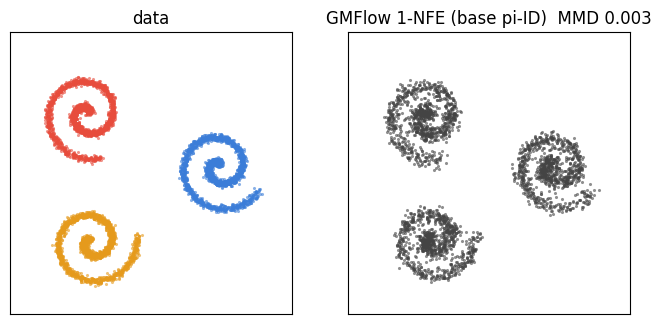

In [14]:
gmflow_policy_net = GMFlowPolicyNet(n_components=24)
gmflow_policy = train_gmflow(gmflow_policy_net, teacher, n_steps=4000).make(gmflow_policy_net)
samples_gmflow = sample_gmflow(gmflow_policy, 3000)
print(f"MMD GMFlow 1-NFE = {mmd(samples_gmflow, data):.4f}   (teacher@200 = {mmd(samples_teacher, data):.4f})")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
scatter(axes[0], data, labels)
axes[0].set_title("data")
scatter(axes[1], samples_gmflow)
axes[1].set_title(f"GMFlow 1-NFE (base pi-ID)  MMD {mmd(samples_gmflow, data):.3f}")
plt.show()

### Почему GMFlow робастна, а DX — нет

Фиксируем **один** старт и смотрим поле скорости каждой политики над плоскостью при фиксированном $t$.
DX замораживает один план → поле тянет к **одной** цели. GMFlow пересчитывает постериор по тому,
**где** сейчас точка → **многобассейновое** поле, тянет к ближайшей моде (error correction).

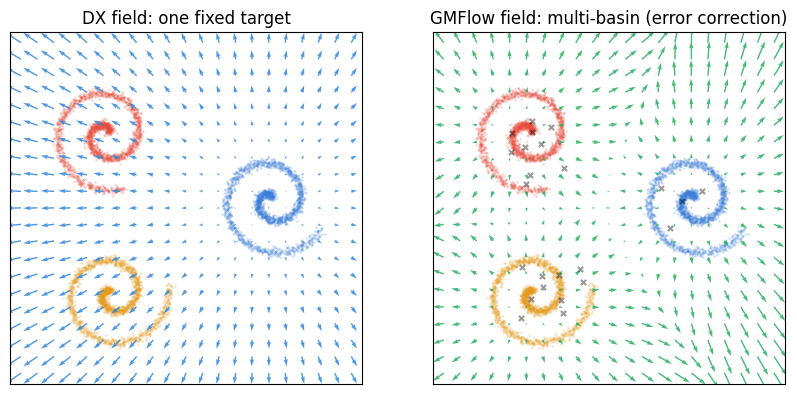

In [15]:
grid_axis = torch.linspace(-3, 3, 21)
grid_x, grid_y = torch.meshgrid(grid_axis, grid_axis, indexing="xy")
grid_points = torch.stack([grid_x.reshape(-1), grid_y.reshape(-1)], dim=1)

torch.manual_seed(3)
x_start = torch.randn(1, 2)
t_fixed = 0.45
n_grid_points = len(grid_points)
with torch.no_grad():
    one = torch.ones(1)
    single_policy = DXPolicy(dx_policy(x_start, one), x_start, one, one, one, 1.0)
    dx_field = single_policy.velocity(grid_points, torch.full((n_grid_points,), t_fixed))
    weights1, centers1, scale1 = gmflow_policy(x_start, torch.ones(1))
    gmflow_field, _, _ = gmflow_velocity(
        weights1.expand(n_grid_points, -1), centers1.expand(n_grid_points, -1, -1),
        scale1.expand(n_grid_points), grid_points, torch.full((n_grid_points,), t_fixed))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
scatter(axes[0], data, labels, size=3, alpha=0.25)
axes[0].quiver(grid_points[:, 0], grid_points[:, 1], dx_field[:, 0], dx_field[:, 1],
               color=DX_COLOR, alpha=0.85, width=0.004)
axes[0].set_title("DX field: one fixed target")
scatter(axes[1], data, labels, size=3, alpha=0.25)
axes[1].quiver(grid_points[:, 0], grid_points[:, 1], gmflow_field[:, 0], gmflow_field[:, 1],
               color=GMFLOW_COLOR, alpha=0.85, width=0.004)
axes[1].scatter(centers1[0, :, 0], centers1[0, :, 1], c="k", marker="x", s=14, alpha=0.4)  # mixture centers
axes[1].set_title("GMFlow field: multi-basin (error correction)")
plt.show()

### Суть NFE: один вызов сети ≠ число шагов интегрирования

Самый важный график. Делаем **один** forward (DX-сетка / GMFlow-смесь), а дальше интегрируем
политику **густо** — сотня network-free подшагов **без** новых вызовов сети. NFE отвязан от
числа ODE-шагов: траектории гладкие, хотя сеть звали ровно раз.

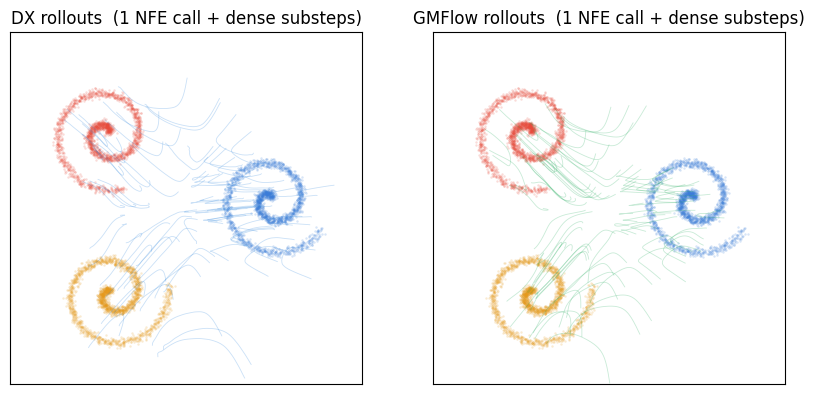

In [16]:
# The real NFE point: 1 network call -> many network-free substeps (dense integration).
_, trajectory_dx = sample_dx(dx_policy, 160, nfe=1, return_trajectory=True)
_, trajectory_gmflow = sample_gmflow(gmflow_policy, 160, return_trajectory=True)
traj_dx = torch.stack(trajectory_dx)
traj_gmflow = torch.stack(trajectory_gmflow)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, traj, title, color in [(axes[0], traj_dx, "DX rollouts", DX_COLOR),
                               (axes[1], traj_gmflow, "GMFlow rollouts", GMFLOW_COLOR)]:
    scatter(ax, data, labels, size=3, alpha=0.2)
    for i in range(0, 160, 2):
        ax.plot(traj[:, i, 0], traj[:, i, 1], color=color, alpha=0.25, lw=0.6)
    ax.set_title(title + "  (1 NFE call + dense substeps)")
plt.show()

## Part 5 — Сравнение

Пять панелей в ряд: **data** → **teacher @200** (потолок качества) → **DX 1-NFE off+win** →
**GMFlow 1-NFE** → **DX naive** (тот же base π-ID, что и GMFlow, — коллапс). Под ними — MMD
к данным (меньше = лучше). На что смотреть: DX off+win ловит все три моды, но мягче; GMFlow
при том же 1-NFE даёт **чёткие** спирали; naive-DX схлопывается.

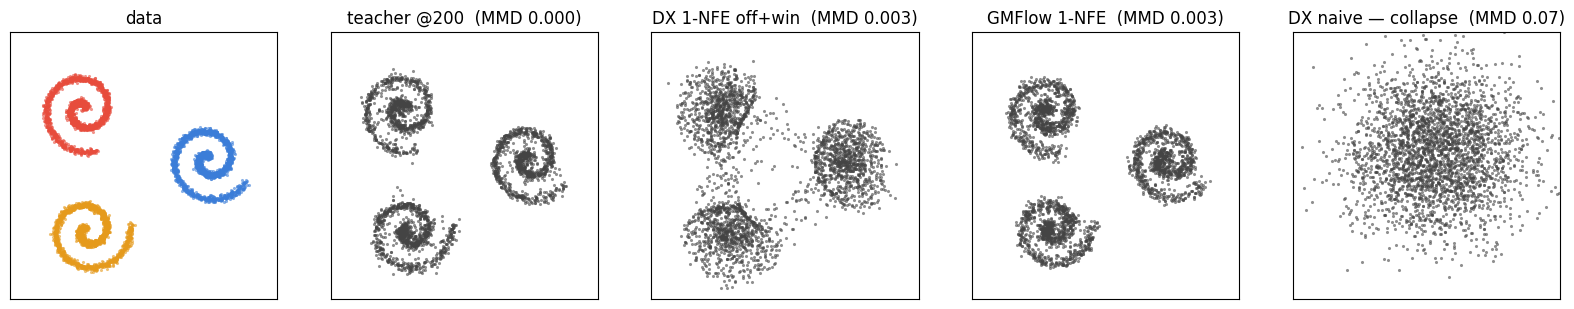

Summary — MMD to data (lower is better):
  teacher @200       : 0.0005
  teacher @4         : 0.0167
  DX off+window 1-NFE: 0.0026   (captures modes; softer than GMFlow)
  GMFlow 1-NFE       : 0.0029   (crisp spirals; robust by construction)
  DX naive (collapse): 0.0696


In [17]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4.2))
panels = [(data, "data", labels),
          (samples_teacher, f"teacher @200  (MMD {mmd(samples_teacher, data):.3f})", None),
          (samples_dx, f"DX 1-NFE off+win  (MMD {mmd(samples_dx, data):.3f})", None),
          (samples_gmflow, f"GMFlow 1-NFE  (MMD {mmd(samples_gmflow, data):.3f})", None),
          (samples_naive, f"DX naive — collapse  (MMD {mmd(samples_naive, data):.2f})", None)]
for ax, (points, title, panel_labels) in zip(axes, panels):
    scatter(ax, points, panel_labels)
    ax.set_title(title)
plt.show()

print("Summary — MMD to data (lower is better):")
print(f"  teacher @200       : {mmd(samples_teacher, data):.4f}")
print(f"  teacher @4         : {mmd(samples_teacher_4step, data):.4f}")
print(f"  DX off+window 1-NFE: {mmd(samples_dx, data):.4f}   (captures modes; softer than GMFlow)")
print(f"  GMFlow 1-NFE       : {mmd(samples_gmflow, data):.4f}   (crisp spirals; robust by construction)")
print(f"  DX naive (collapse): {mmd(samples_naive, data):.4f}")

## Заключение

- **DX**: сеть выдаёт $u$-сетку → $\hat x_0$-сетку, скорость интерполяцией.
  Хрупкий: обучается только **off-policy** (катимся по учителю) + **window-avg**. На том же базовом
  on-policy π-ID, что и GMFlow, — **коллапсирует**. Ловит моды, но **мягче** GMFlow (это реальный
  зазор выразительности: в статье DX 1-NFE FID 4.44 vs GMFlow 2.85).
- **GMFlow**: гауссова смесь + closed-form постериор, зависящий от $x_t$ → **робастна по построению**.
  Обучается простым on-policy π-ID, 1-NFE даёт **чёткие спирали**.
- **NFE**: на этой лёгкой 2D задаче 1-NFE уже лучший — больше сегментов не помогает (на полноразмерных моделях
  `nfe` берут больше, напр. 16, потому что **на сложных данных** NFE важен). Настоящая суть NFE здесь — на картинке
  траекторий: **1 вызов сети + сотня network-free подшагов**.
- **shift** (в реальных видео-моделях, напр. `shift=5`) заточен под высокое разрешение; на toy он скорее мешает.

**Поиграться:** число точек $N$ у DX (больше → острее, до предела), число компонент $K$ у GMFlow,
`policy_mode`/`window_substeps`/`nfe`/`shift` в `train_dx`.